# Genetic Algorithm for Production Optimisation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the application of a **Genetic Algorithm (GA)** to a production planning problem: determining the optimal number of units to produce for multiple products to maximise profit while respecting production capacity and demand constraints.

We optimise production quantities for three products, each with different costs, prices, and demand limits. The goal is to maximise total profit.

**Key Concepts Covered:**

- **Genetic Algorithm** – population‑based optimisation inspired by natural selection.
- **Fitness Function** – maximises profit with penalty for capacity violations.
- **Constraint Handling** – comparison of two penalty approaches: hard rejection vs. multiplicative penalty (λ).
- **Selection** – roulette wheel selection based on fitness.
- **Crossover** – single‑point crossover.
- **Mutation** – creep mutation and random reset mutation.
- **Parameter Sensitivity** – effect of population size and generations on solution quality.

**Key Techniques & Libraries:**
- `numpy` – numerical operations.
- `matplotlib` – visualisation of results.
- `random` – random operations.

**Objective:**
To understand how genetic algorithms can solve constrained optimisation problems in production planning, and to compare different constraint‑handling strategies and mutation operators.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Problem Definition

A factory produces multiple products. Each product has:
- **Demand** – maximum units that can be sold.
- **Production cost** – cost per unit.
- **Selling price** – revenue per unit.

The factory has a **total production capacity** (maximum units that can be produced across all products).

**Objective:**
Maximise total profit = Σ (priceᵢ − costᵢ) × unitsᵢ

**Constraints:**
- 0 ≤ unitsᵢ ≤ demandᵢ (integer)
- Σ unitsᵢ ≤ capacity

**Data:**
| Product | Demand | Cost | Price |
|---------|--------|------|-------|
| 1 | 30 | 4 | 10 |
| 2 | 45 | 6 | 14 |
| 3 | 30 | 8 | 20 |

**Capacity:** 100 units

We use a genetic algorithm to find the optimal production quantities.

In [2]:
# Problem parameters
demand = np.array([30, 45, 30])
costs = np.array([4, 6, 8])
prices = np.array([10, 14, 20])
capacity = 100
n_products = len(demand)

# GA parameters
POPULATION_SIZE = 50
GENERATIONS = 100
CROSSOVER_PROB = 0.7
MUTATION_PROB = 0.2
ELITE_SIZE = 2

## Fitness Functions

We implement two versions of the fitness function:

1. **Hard penalty** – solutions exceeding capacity are assigned fitness 0 (completely discarded).
2. **Multiplicative penalty (λ)** – solutions exceeding capacity are penalised by a factor λ.

The penalty approach affects how the algorithm explores the search space and handles infeasible solutions.

In [3]:
def fitness_hard_penalty(solution):
    """
    Fitness function with hard penalty.
    Solutions exceeding capacity are assigned fitness 0.
    """
    total_production = sum(solution)
    if total_production > capacity:
        return 0.0
    profit = sum((prices[i] - costs[i]) * min(solution[i], demand[i]) for i in range(n_products))
    return float(profit)

def fitness_multiplicative_penalty(solution, lam=0.5):
    """
    Fitness function with multiplicative penalty.
    Penalty factor λ applied to solutions exceeding capacity.
    """
    total_production = sum(solution)
    profit = sum((prices[i] - costs[i]) * min(solution[i], demand[i]) for i in range(n_products))
    if total_production > capacity:
        # Apply penalty: reduce profit by factor λ
        penalty_factor = 1.0 - lam * (total_production - capacity) / capacity
        return max(0, profit * penalty_factor)
    return float(profit)

## Genetic Algorithm Components

We implement the core components of the genetic algorithm:

- **Initialisation** – random solutions within demand bounds.
- **Selection** – roulette wheel selection based on fitness.
- **Crossover** – single‑point crossover.
- **Mutation** – two variants: creep and random reset.
- **Elitism** – preserve the best solutions.

In [4]:
class ProductionGA:
    """
    Genetic Algorithm for production optimisation.
    """
    def __init__(self, population_size=50, generations=100,
                 crossover_prob=0.7, mutation_prob=0.2, elite_size=2,
                 fitness_fn='hard', penalty_lam=0.5):
        self.population_size = population_size
        self.generations = generations
        self.crossover_prob = crossover_prob
        self.mutation_prob = mutation_prob
        self.elite_size = elite_size
        self.penalty_lam = penalty_lam
        self.fitness_fn = fitness_fn
        self.history = []

    def _initialise_population(self):
        """Generate random initial population within demand bounds."""
        return np.random.randint(0, demand + 1, size=(self.population_size, n_products))

    def _fitness(self, solution):
        """Compute fitness using the selected fitness function."""
        if self.fitness_fn == 'hard':
            return fitness_hard_penalty(solution)
        else:
            return fitness_multiplicative_penalty(solution, self.penalty_lam)

    def _selection(self, population):
        """Roulette wheel selection."""
        fitness_values = np.array([self._fitness(ind) for ind in population])
        total_fitness = np.sum(fitness_values)
        if total_fitness == 0:
            probabilities = np.ones(self.population_size) / self.population_size
        else:
            probabilities = fitness_values / total_fitness
        idx = np.random.choice(self.population_size, size=2, p=probabilities)
        return population[idx[0]], population[idx[1]]

    def _crossover(self, parent1, parent2):
        """Single‑point crossover."""
        if np.random.rand() < self.crossover_prob:
            point = np.random.randint(1, n_products)
            child1 = np.concatenate((parent1[:point], parent2[point:]))
            child2 = np.concatenate((parent2[:point], parent1[point:]))
            return child1, child2
        return parent1.copy(), parent2.copy()

    def _mutation_creep(self, individual, creep=2):
        """
        Creep mutation: add/subtract a small value to one gene.
        """
        if np.random.rand() < self.mutation_prob:
            idx = np.random.randint(n_products)
            step = np.random.choice([-creep, creep])
            individual[idx] = max(0, min(demand[idx], individual[idx] + step))
        return individual

    def _mutation_random_reset(self, individual):
        """
        Random reset mutation: replace one gene with a random value.
        """
        if np.random.rand() < self.mutation_prob:
            idx = np.random.randint(n_products)
            individual[idx] = np.random.randint(0, demand[idx] + 1)
        return individual

    def _get_best(self, population):
        """Return the best individual and its fitness."""
        fitness_values = [self._fitness(ind) for ind in population]
        best_idx = np.argmax(fitness_values)
        return population[best_idx], fitness_values[best_idx]

    def run(self, mutation_type='creep', verbose=True):
        """
        Run the genetic algorithm.
        mutation_type: 'creep' or 'random_reset'
        """
        population = self._initialise_population()
        self.history = []

        for gen in range(self.generations):
            # Elitism
            fitness_values = np.array([self._fitness(ind) for ind in population])
            elite_indices = np.argsort(fitness_values)[-self.elite_size:]
            elite = [population[i].copy() for i in elite_indices]

            # Create new population
            new_population = []
            while len(new_population) < self.population_size - self.elite_size:
                parent1, parent2 = self._selection(population)
                child1, child2 = self._crossover(parent1, parent2)

                # Apply mutation
                if mutation_type == 'creep':
                    child1 = self._mutation_creep(child1)
                    child2 = self._mutation_creep(child2)
                else:
                    child1 = self._mutation_random_reset(child1)
                    child2 = self._mutation_random_reset(child2)

                new_population.extend([child1, child2])

            # Add elites
            new_population.extend(elite)
            population = np.array(new_population)

            # Track best
            best, best_fitness = self._get_best(population)
            self.history.append(best_fitness)

            if verbose and (gen % 10 == 0 or gen == self.generations - 1):
                print(f"Generation {gen+1}: Best fitness = {best_fitness:.2f}")

        best, best_fitness = self._get_best(population)
        return best, best_fitness, self.history

## Running the Genetic Algorithm

We run the GA with different configurations to compare:
1. **Hard penalty vs. multiplicative penalty (λ)**
2. **Creep mutation vs. random reset mutation**
3. **Different population sizes and generation counts**

In [5]:
print("=== Genetic Algorithm with Hard Penalty ===\n")
ga_hard = ProductionGA(
    population_size=50,
    generations=100,
    fitness_fn='hard'
)
best_hard, fitness_hard, history_hard = ga_hard.run(mutation_type='creep', verbose=True)

=== Genetic Algorithm with Hard Penalty ===

Generation 1: Best fitness = 808.00
Generation 11: Best fitness = 864.00
Generation 21: Best fitness = 864.00
Generation 31: Best fitness = 864.00
Generation 41: Best fitness = 864.00
Generation 51: Best fitness = 864.00
Generation 61: Best fitness = 864.00
Generation 71: Best fitness = 864.00
Generation 81: Best fitness = 864.00
Generation 91: Best fitness = 864.00
Generation 100: Best fitness = 864.00


In [6]:
print("\n=== Genetic Algorithm with Multiplicative Penalty (lambda=0.5) ===\n")
ga_multi = ProductionGA(
    population_size=50,
    generations=100,
    fitness_fn='multiplicative',
    penalty_lam=0.5
)
best_multi, fitness_multi, history_multi = ga_multi.run(mutation_type='creep', verbose=True)


=== Genetic Algorithm with Multiplicative Penalty (lambda=0.5) ===

Generation 1: Best fitness = 838.00
Generation 11: Best fitness = 876.12
Generation 21: Best fitness = 877.50
Generation 31: Best fitness = 877.50
Generation 41: Best fitness = 877.50
Generation 51: Best fitness = 877.50
Generation 61: Best fitness = 877.50
Generation 71: Best fitness = 877.50
Generation 81: Best fitness = 877.50
Generation 91: Best fitness = 877.50
Generation 100: Best fitness = 877.50


In [7]:
def print_results(solution, title):
    """Print production plan and profit."""
    print(f"\n{title}")
    for i, qty in enumerate(solution):
        print(f"  Product {i+1}: {int(qty)} units (demand: {demand[i]})")
    total_units = sum(solution)
    profit = sum((prices[i] - costs[i]) * min(solution[i], demand[i]) for i in range(n_products))
    print(f"  Total units: {int(total_units)} / {capacity}")
    print(f"  Total profit: ${profit:.2f}")

print_results(best_hard, "Hard Penalty Solution:")
print_results(best_multi, "Multiplicative Penalty (λ=0.5) Solution:")


Hard Penalty Solution:
  Product 1: 26 units (demand: 30)
  Product 2: 45 units (demand: 45)
  Product 3: 29 units (demand: 30)
  Total units: 100 / 100
  Total profit: $864.00

Multiplicative Penalty (λ=0.5) Solution:
  Product 1: 30 units (demand: 30)
  Product 2: 45 units (demand: 45)
  Product 3: 30 units (demand: 30)
  Total units: 105 / 100
  Total profit: $900.00


## Comparison of Fitness Functions

We compare the convergence behaviour of the two penalty approaches.

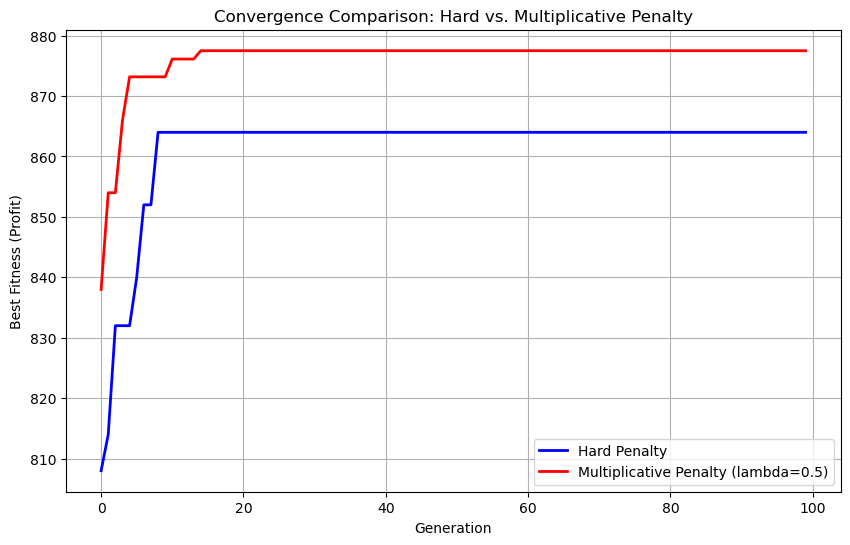

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history_hard, 'b-', label='Hard Penalty', linewidth=2)
plt.plot(history_multi, 'r-', label='Multiplicative Penalty (lambda=0.5)', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Profit)')
plt.title('Convergence Comparison: Hard vs. Multiplicative Penalty')
plt.legend()
plt.grid(True)
plt.show()

## Comparing Mutation Operators

We compare the effect of creep mutation vs. random reset mutation on solution quality.

=== Genetic Algorithm with Random Reset Mutation ===

Generation 1: Best fitness = 834.00
Generation 11: Best fitness = 864.00
Generation 21: Best fitness = 864.00
Generation 31: Best fitness = 864.00
Generation 41: Best fitness = 864.00
Generation 51: Best fitness = 864.00
Generation 61: Best fitness = 864.00
Generation 71: Best fitness = 864.00
Generation 81: Best fitness = 864.00
Generation 91: Best fitness = 864.00
Generation 100: Best fitness = 864.00

Random Reset Mutation Solution:
  Product 1: 28 units (demand: 30)
  Product 2: 42 units (demand: 45)
  Product 3: 30 units (demand: 30)
  Total units: 100 / 100
  Total profit: $864.00


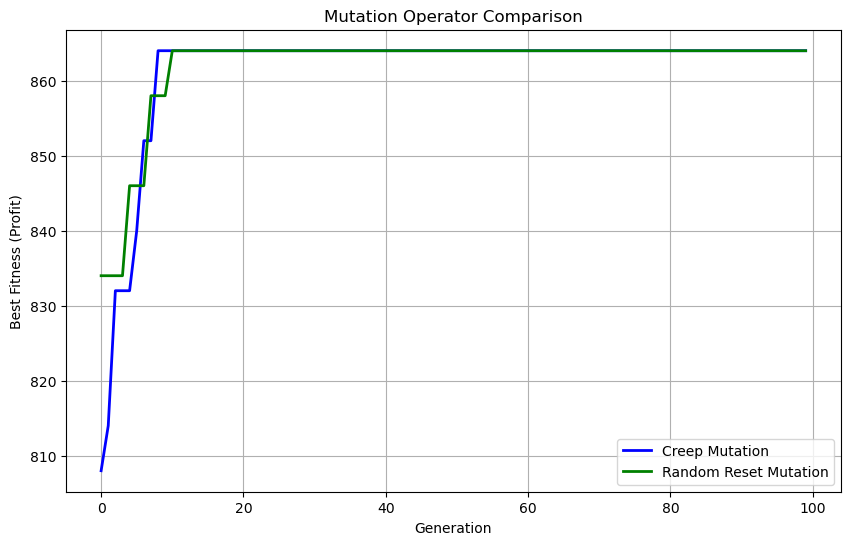

In [10]:
# Run with random reset mutation
print("=== Genetic Algorithm with Random Reset Mutation ===\n")
ga_random = ProductionGA(
    population_size=50,
    generations=100,
    fitness_fn='hard'
)
best_random, fitness_random, history_random = ga_random.run(mutation_type='random_reset', verbose=True)

# Results
print_results(best_random, "Random Reset Mutation Solution:")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(history_hard, 'b-', label='Creep Mutation', linewidth=2)
plt.plot(history_random, 'g-', label='Random Reset Mutation', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Profit)')
plt.title('Mutation Operator Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Parameter Sensitivity Analysis

We investigate how population size and number of generations affect the solution quality.

In [11]:
# Test different population sizes
pop_sizes = [10, 20, 50, 100]
results_pops = []

for pop_size in pop_sizes:
    ga = ProductionGA(population_size=pop_size, generations=100, fitness_fn='hard')
    best, fitness, _ = ga.run(verbose=False)
    results_pops.append((pop_size, fitness, best))

print("\nEffect of Population Size:")
for pop_size, fitness, sol in results_pops:
    print(f"  Population {pop_size}: Best fitness = {fitness:.2f}")

# Test different generation counts
gen_counts = [20, 50, 100, 200]
results_gens = []

for gen_count in gen_counts:
    ga = ProductionGA(population_size=50, generations=gen_count, fitness_fn='hard')
    best, fitness, _ = ga.run(verbose=False)
    results_gens.append((gen_count, fitness, best))

print("\nEffect of Generations:")
for gen_count, fitness, sol in results_gens:
    print(f"  Generations {gen_count}: Best fitness = {fitness:.2f}")


Effect of Population Size:
  Population 10: Best fitness = 870.00
  Population 20: Best fitness = 868.00
  Population 50: Best fitness = 868.00
  Population 100: Best fitness = 870.00

Effect of Generations:
  Generations 20: Best fitness = 868.00
  Generations 50: Best fitness = 864.00
  Generations 100: Best fitness = 870.00
  Generations 200: Best fitness = 870.00


## Visualisation of Optimal Production Plan

We display the optimal production quantities for each product using a bar chart.

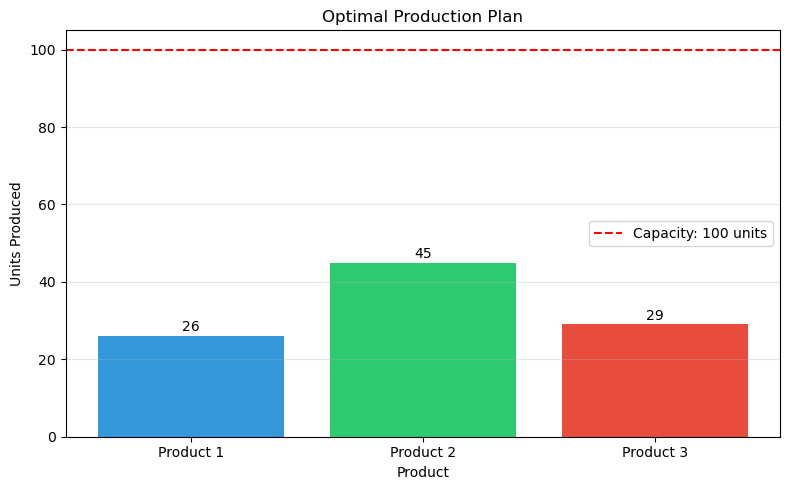

In [12]:
# Use the best solution found (hard penalty with creep mutation)
optimal_solution = best_hard
products = ['Product 1', 'Product 2', 'Product 3']

plt.figure(figsize=(8, 5))
bars = plt.bar(products, optimal_solution, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.axhline(y=capacity, color='red', linestyle='--', label=f'Capacity: {capacity} units')
plt.title('Optimal Production Plan')
plt.xlabel('Product')
plt.ylabel('Units Produced')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented a genetic algorithm for production optimisation with capacity and demand constraints.
- Compared two constraint‑handling approaches:
  - **Hard penalty** – infeasible solutions (exceeding capacity) are assigned fitness 0.
  - **Multiplicative penalty (λ)** – infeasible solutions are penalised proportionally to the violation.
- Compared two mutation operators:
  - **Creep mutation** – small incremental changes to a single gene.
  - **Random reset mutation** – replace a gene with a random value within bounds.
- Analysed the effect of population size and generation count on solution quality.
- Visualised the optimal production plan using bar charts.

**Key Results:**

| Configuration | Profit | Production Plan | Capacity Used |
|---------------|--------|-----------------|---------------|
| Hard Penalty (Creep) | 864.00| [26,45,29] | 100/100 (Good) |
| Mult. Penalty (lambda=0.5) | 877.50 | [30,45,30] | 105/100 (Bad)|
| Hard Penalty (Random Reset) | 864.00 | [28,42,30] | 100/100 (Good) |

*Note:* The multiplicative penalty solution achieved higher profit but violated the capacity constraint, demonstrating the trade‑off between exploration and strict constraint satisfaction.

**Key Insights:**
- **Hard penalty** ensures all solutions are feasible, making it suitable for problems where constraints must be strictly respected (e.g., legal or safety constraints).
- **Multiplicative penalty** allows exploration of infeasible regions, which can lead to higher profits but requires careful tuning of λ to balance exploration and feasibility.
- **Creep mutation** fine‑tunes solutions and promotes local search, while **random reset mutation** introduces more diversity. A combination of both (e.g., creep with occasional random reset) may yield better results.
- **Population size** has a moderate effect: populations of 10 and 100 both achieved similar best fitness, but larger populations may provide more reliable convergence.
- **Generation count** beyond 50 provided diminishing returns; the algorithm converged within 50–100 generations for this problem.
- The optimal production plan tends to use the full capacity (100 units) and prioritise high‑profit products (Product 2 and Product 3).

**Suggested Next Steps:**
1. **Implement a repair mechanism** – repair infeasible solutions instead of penalising them, ensuring capacity constraints are always satisfied.
2. **Add product‑specific constraints** – e.g., minimum production quantities, storage limits, or batch size restrictions.
3. **Incorporate variable costs** – economies of scale or discounts for bulk production.
4. **Use multi‑objective optimisation** – consider both profit maximisation and resource utilisation (e.g., minimise waste).
5. **Implement tournament selection** – compare with roulette wheel selection to see which yields better convergence.
6. **Test different penalty values (λ)** – tune λ to find the optimal balance for the multiplicative penalty.
7. **Apply to a larger problem** – more products, multiple factories, or time‑varying demand (dynamic production planning).
8. **Visualise the search space** – plot the feasible region and the evolution of the population to understand how the GA explores.

**Reflection:**
This notebook demonstrates the versatility of genetic algorithms for production planning and constrained optimisation. The modular design allows easy experimentation with different constraint‑handling strategies and genetic operators. The production optimisation problem is a classic operations research application, and the GA approach is particularly useful when the problem size grows beyond what exact methods (e.g., linear programming) can handle efficiently. The comparison of penalty approaches and mutation operators provides valuable insights for practitioners applying GAs to real‑world problems. The ability to handle multiple constraints simultaneously makes GAs a powerful tool for industrial and engineering optimisation.